<a href="https://colab.research.google.com/github/KesariBharathReddy/IAIP/blob/main/Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv('data.csv', encoding='latin1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [2]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [3]:
df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int)
df = df[df['Quantity']>0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397924 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397924 non-null  object        
 1   StockCode    397924 non-null  object        
 2   Description  397924 non-null  object        
 3   Quantity     397924 non-null  int64         
 4   InvoiceDate  397924 non-null  datetime64[ns]
 5   UnitPrice    397924 non-null  float64       
 6   CustomerID   397924 non-null  int64         
 7   Country      397924 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 27.3+ MB


In [4]:
df['TotalPrice'] = df['Quantity']* df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [5]:
import datetime as dt
reference_date = df['InvoiceDate'].max()+dt.timedelta(days=1)
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate':lambda x: (reference_date -x.max()).days,
    'InvoiceNo':'nunique',
    'TotalPrice':'sum'

})
rfm.columns = ['Recency','Frequency','Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [6]:
rfm.describe()

,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000
mean,92.518322,4.271952,2053.793018
std,100.009747,7.705493,8988.248381
min,1.000000,1.000000,0.000000
25%,18.000000,1.000000,307.245000
50%,51.000000,2.000000,674.450000
75%,142.000000,5.000000,1661.640000
max,374.000000,210.000000,280206.020000


In [7]:
def remove_outliers(df,column):
  Q1=df[column].quantile(0.25)
  Q3=df[column].quantile(0.75)
  IQR=Q3-Q1
  lower_bound=Q1-1.5*IQR
  upper_bound = Q3 + 1.5 * IQR
  return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

rfm_clean = rfm.copy()
for col in ['Recency', 'Frequency', 'Monetary']:
    rfm_clean = remove_outliers(rfm_clean, col)

print("Original customers:", rfm.shape[0])
print("After removing outliers:", rfm_clean.shape[0])
rfm_clean.describe()



Original customers: 4339
After removing outliers: 3603


,Recency,Frequency,Monetary
count,3603.000000,3603.000000,3603.000000
mean,91.606439,2.722176,813.028097
std,89.483899,2.075538,701.328581
min,1.000000,1.000000,0.000000
25%,22.000000,1.000000,287.880000
50%,57.000000,2.000000,580.050000
75%,144.500000,4.000000,1141.675000
max,327.000000,11.000000,3029.870000


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_clean)

rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'], index=rfm_clean.index)
rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12348,-0.185606,0.615745,1.403548
12349,-0.811504,-0.829865,1.346948
12350,2.440929,-0.829865,-0.682554
12352,-0.621499,2.543224,2.414342
12353,1.256194,-0.829865,-1.032510


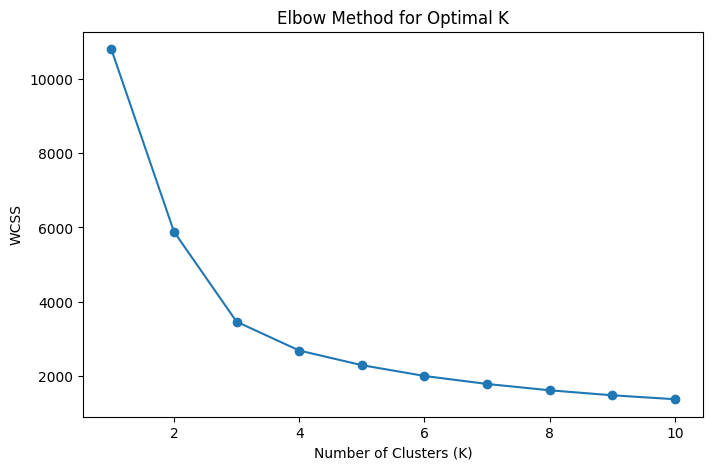

In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.show()

In [10]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm_clean['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm_clean.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12348,75,4,1797.24,3
12349,19,1,1757.55,3
12350,310,1,334.40,1
12352,36,8,2506.04,2
12353,204,1,89.00,1


In [11]:
cluster_summary = rfm_clean.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
cluster_summary['Count'] = rfm_clean['Cluster'].value_counts()
cluster_summary

,Recency,Frequency,Monetary,Count
Cluster,,,,
0,52.115901,1.592226,407.143372,1415
1,231.008028,1.477064,399.629140,872
2,32.085526,6.743421,2146.036404,456
3,46.795349,3.711628,1193.212966,860


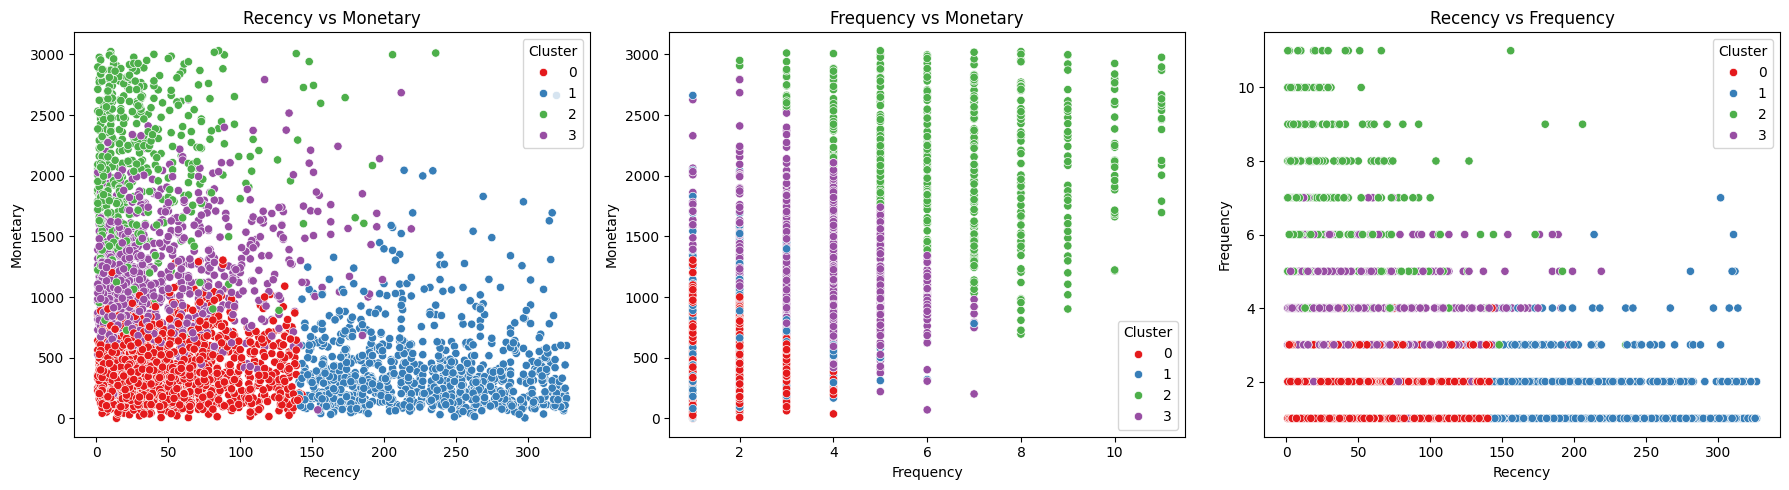

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recency vs Monetary
sns.scatterplot(data=rfm_clean, x='Recency', y='Monetary', hue='Cluster', palette='Set1', ax=axes[0])
axes[0].set_title('Recency vs Monetary')

# Frequency vs Monetary
sns.scatterplot(data=rfm_clean, x='Frequency', y='Monetary', hue='Cluster', palette='Set1', ax=axes[1])
axes[1].set_title('Frequency vs Monetary')

# Recency vs Frequency
sns.scatterplot(data=rfm_clean, x='Recency', y='Frequency', hue='Cluster', palette='Set1', ax=axes[2])
axes[2].set_title('Recency vs Frequency')

plt.tight_layout()
plt.show()

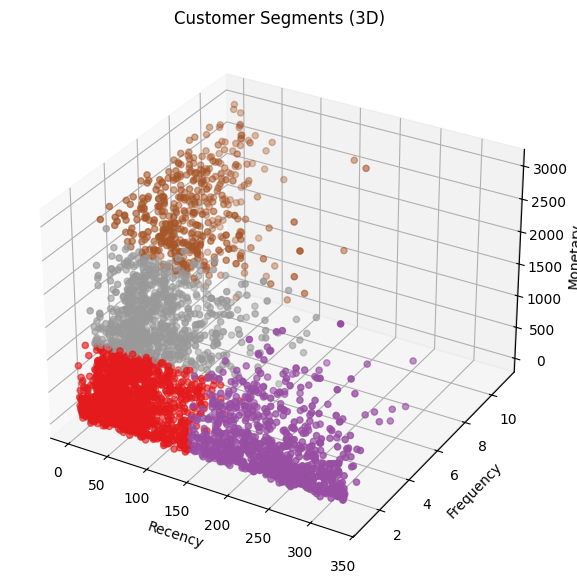

In [13]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(rfm_clean['Recency'], rfm_clean['Frequency'], rfm_clean['Monetary'],
                      c=rfm_clean['Cluster'], cmap='Set1')

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
plt.title('Customer Segments (3D)')
plt.show()